Conteúdo:

dataset overview\
missing values\
distribution plots\
survival analysis\
correlations\
insights

Gráficos típicos:

survival by sex\
survival by class\
age distribution\
fare distribution\
correlation heatmap

## Imports and functions

In [659]:
# Imports
import numpy as np
import pandas as pd

# Statistics
import statsmodels.api as sm
import scipy.stats as stats
from scipy.stats import bootstrap
from sklearn.datasets import fetch_california_housing

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [660]:
def statistic(_dataset):
  """
  DOCSTRING:
  Describe (without count) + Insert range: max - min
  """
  _describe = _dataset.describe()
  _describe = _describe.drop('count')
  _size = _describe.shape
  _describe.loc['range'] = _describe['max'] - _describe['min']
  _describe.loc['mode'] = stats.mode(_dataset, keepdims = False)[0]
  _describe = np.around(_describe.sort_values(), 2)
  return _describe

def PlotarStatistic(dataset, yLabel = None, title = "ESTATÍSTICA DESCRITIVA DO DATASET"):

  _describe = statistic(dataset)

  # Símbolos da estatística estimada da população
  mean_mu = 'MÉDIA:  $\\overline{\mu}$ = '
  mean_mu += f'{_describe["mean"]: .2f}'

  median_mu = 'MEDIANA: $\\tilde{\mu}$ = '
  median_mu += f'{_describe["50%"]: .2f}'

  mode_mu = 'MODA: $\\hat{\mu}$ = '
  mode_mu += f'{_describe["mode"]: .2f}'

  enter = '\n'

  label = mean_mu + enter + median_mu + enter + mode_mu
  dataset.agg(statistic).plot(figsize = [15, 6], label='MEDIDAS DE RESUMO: ')
  plt.plot(list(_describe.index).index('mean'), _describe["mean"], 'D', label=mean_mu)
  plt.plot(list(_describe.index).index('50%'), _describe["50%"], 'D', label=median_mu)
  plt.plot(list(_describe.index).index('mode'), _describe["mode"], 'D', label=mode_mu)

  plt.title(f'{title}')
  plt.legend()
  plt.ylabel(yLabel)
  plt.show()
  print('ESTATÍSTICA DESCRITIVA DO DATASET:')
  print(_describe)

In [661]:
def data_summarize(data, column, count = True, train = True):
    print(f'Unique values total: {data[column].nunique()}')
    print(f'\nUnique values: {data[column].unique()}')
    print(f'\nNull: {data[column].isnull().sum()}')
    print(f'\nCount: \n{data[column].value_counts()}')
    
    if count:
        if train:
            sns.countplot(data = data, x = column, hue = 'Survived')
        else:
            sns.countplot(data = data, x = column)
    else:
        sns.displot(data[column], kde = True)

## ETL and Data Exploration

In [662]:
# Load
train = pd.read_csv("dataset/train.csv")
test = pd.read_csv("dataset/test.csv")

train_bkp = train.copy()
test_bkp = test.copy()

In [663]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [664]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [665]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [666]:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### Survived

Unique values total: 2

Unique values: [0 1]

Null: 0

Count: 
Survived
0    549
1    342
Name: count, dtype: int64


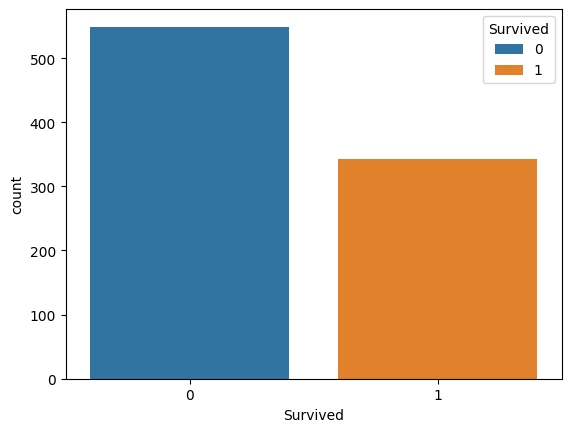

In [667]:
data_summarize(train, 'Survived')

### Pclass

Unique values total: 3

Unique values: [3 1 2]

Null: 0

Count: 
Pclass
3    491
1    216
2    184
Name: count, dtype: int64


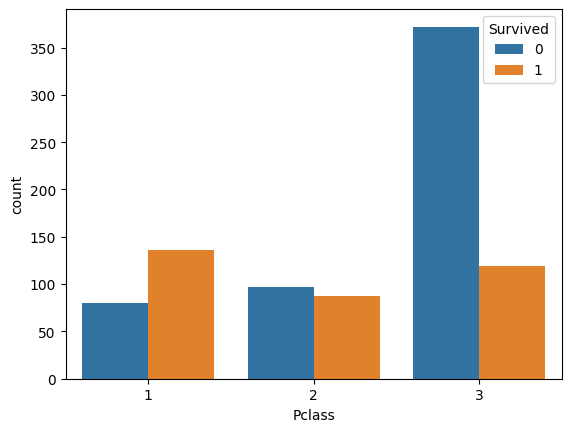

In [668]:
data_summarize(train, 'Pclass')

Unique values total: 3

Unique values: [3 2 1]

Null: 0

Count: 
Pclass
3    218
1    107
2     93
Name: count, dtype: int64


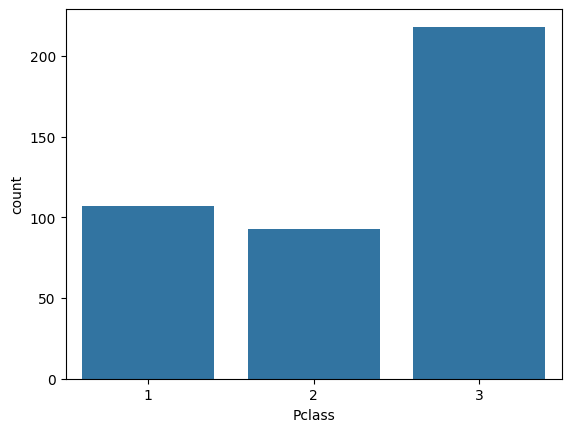

In [669]:
data_summarize(test, 'Pclass', train=False)

As the class value increases, the survival probability decreases.

### Sex

Unique values total: 2

Unique values: ['male' 'female']

Null: 0

Count: 
Sex
male      577
female    314
Name: count, dtype: int64


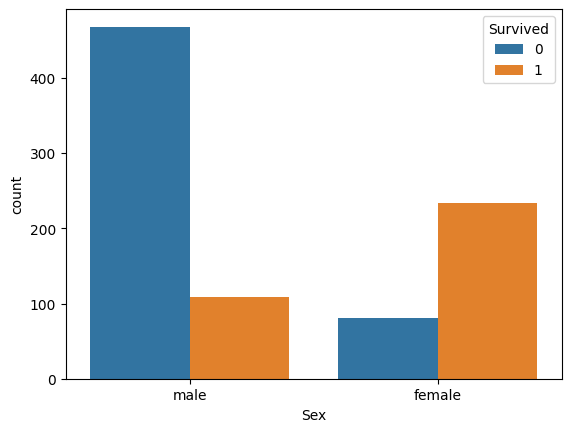

In [670]:
data_summarize(train, 'Sex')

Unique values total: 2

Unique values: ['male' 'female']

Null: 0

Count: 
Sex
male      266
female    152
Name: count, dtype: int64


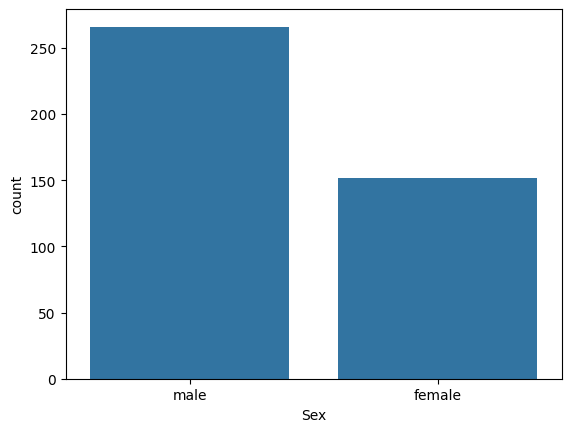

In [671]:
data_summarize(test, 'Sex', train=False)

In [672]:
# Converting string to number
# male: 0 | female: 1

train['Sex'] = train['Sex'].map({'male': 0, 'female': 1})
test['Sex'] = test['Sex'].map({'male': 0, 'female': 1})

Female passengers have a higher survival probability

### Age

Unique values total: 88

Unique values: [22.   38.   26.   35.     nan 54.    2.   27.   14.    4.   58.   20.
 39.   55.   31.   34.   15.   28.    8.   19.   40.   66.   42.   21.
 18.    3.    7.   49.   29.   65.   28.5   5.   11.   45.   17.   32.
 16.   25.    0.83 30.   33.   23.   24.   46.   59.   71.   37.   47.
 14.5  70.5  32.5  12.    9.   36.5  51.   55.5  40.5  44.    1.   61.
 56.   50.   36.   45.5  20.5  62.   41.   52.   63.   23.5   0.92 43.
 60.   10.   64.   13.   48.    0.75 53.   57.   80.   70.   24.5   6.
  0.67 30.5   0.42 34.5  74.  ]

Null: 177

Count: 
Age
24.00    30
22.00    27
18.00    26
19.00    25
28.00    25
         ..
36.50     1
55.50     1
0.92      1
23.50     1
74.00     1
Name: count, Length: 88, dtype: int64


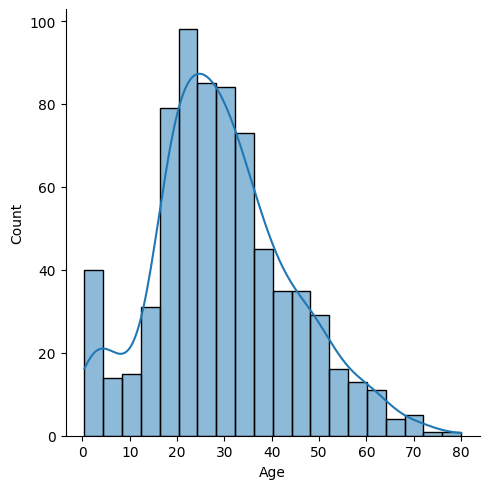

In [673]:
data_summarize(train, 'Age', False)

Unique values total: 79

Unique values: [34.5  47.   62.   27.   22.   14.   30.   26.   18.   21.     nan 46.
 23.   63.   24.   35.   45.   55.    9.   48.   50.   22.5  41.   33.
 18.5  25.   39.   60.   36.   20.   28.   10.   17.   32.   13.   31.
 29.   28.5  32.5   6.   67.   49.    2.   76.   43.   16.    1.   12.
 42.   53.   26.5  40.   61.   60.5   7.   15.   54.   64.   37.   34.
 11.5   8.    0.33 38.   57.   40.5   0.92 19.   36.5   0.75  0.83 58.
  0.17 59.   14.5  44.    5.   51.    3.   38.5 ]

Null: 86

Count: 
Age
21.0    17
24.0    17
22.0    16
30.0    15
18.0    13
        ..
76.0     1
28.5     1
22.5     1
62.0     1
38.5     1
Name: count, Length: 79, dtype: int64


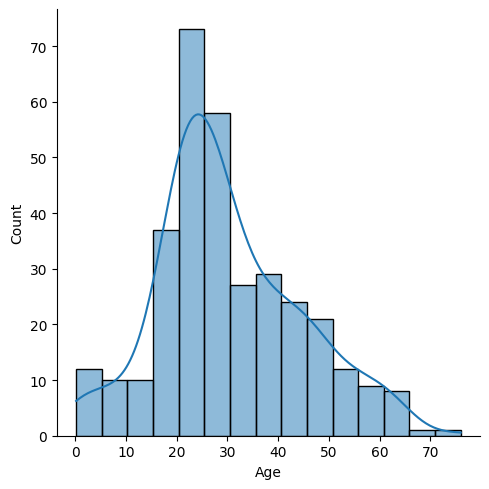

In [674]:
data_summarize(test, 'Age', False, train=False)

In [675]:
#train.corr(numeric_only=True)["Survived"].sort_values(ascending=False)
train.corr(numeric_only=True)

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,-0.042939,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,0.543351,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.131900,-0.369226,0.083081,0.018443,-0.549500
Sex,-0.042939,0.543351,-0.131900,1.000000,-0.093254,0.114631,0.245489,0.182333
Age,0.036847,-0.077221,-0.369226,-0.093254,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,0.114631,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,0.245489,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.182333,0.096067,0.159651,0.216225,1.000000


In [676]:
# Age is right-skewed
train["Age"].skew()

0.38910778230082704

In [677]:
# Mean > Median → distribution is right-skewed
train["Age"].mean(), train["Age"].median()

(29.69911764705882, 28.0)

In [678]:
# Filling NA values with the median of each class
train["Age"] = train["Age"].fillna(
    train.groupby(["Pclass", "Sex"])["Age"].transform("median")
)

# Same in test dataset
test["Age"] = test["Age"].fillna(
    test.groupby(["Pclass", "Sex"])["Age"].transform("median")
)

Age is right-skewed, all missing values were inputed using the median within each class. \
The majority of passengers are between 20 and 30 years old.

### Sibsp

Unique values total: 7

Unique values: [1 0 3 4 2 5 8]

Null: 0

Count: 
SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64


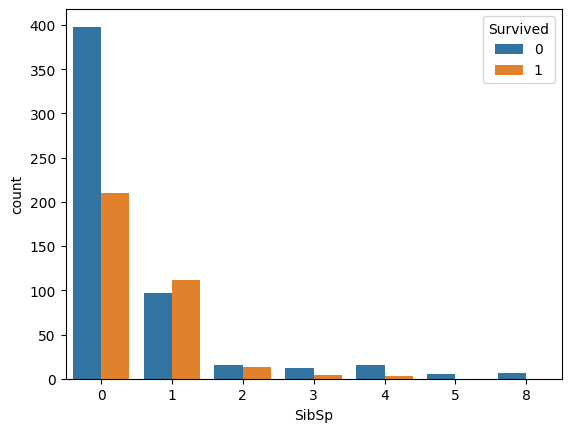

In [679]:
data_summarize(train, 'SibSp')

Unique values total: 7

Unique values: [0 1 2 3 4 5 8]

Null: 0

Count: 
SibSp
0    283
1    110
2     14
3      4
4      4
8      2
5      1
Name: count, dtype: int64


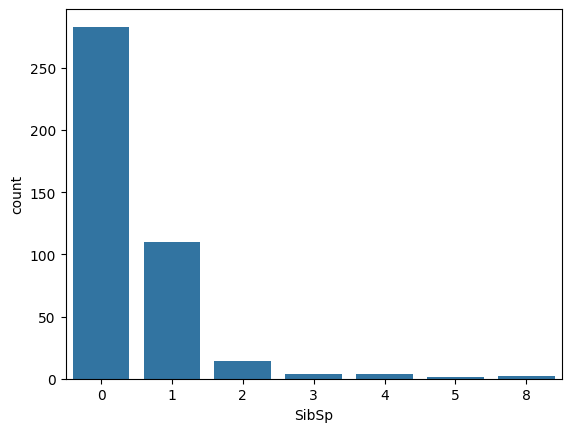

In [680]:
data_summarize(test, 'SibSp', train=False)

### Parch

Unique values total: 7

Unique values: [0 1 2 5 3 4 6]

Null: 0

Count: 
Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64


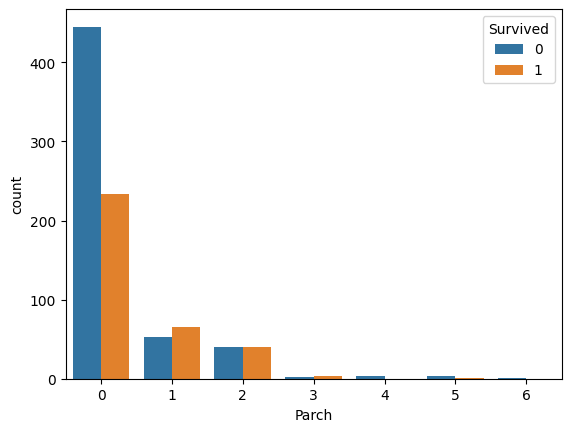

In [681]:
data_summarize(train, 'Parch')

Unique values total: 8

Unique values: [0 1 3 2 4 6 5 9]

Null: 0

Count: 
Parch
0    324
1     52
2     33
3      3
4      2
9      2
6      1
5      1
Name: count, dtype: int64


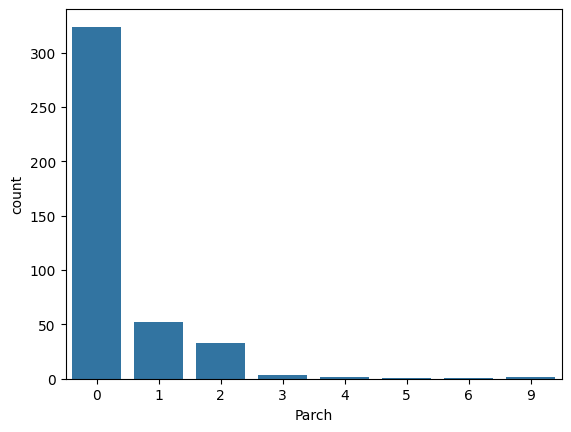

In [682]:
data_summarize(test, 'Parch', train=False)

### Family size

### Fare

In [683]:
print(f'Unique values total: {train["Fare"].nunique()}')
print(f'\nUnique values: {train["Fare"].unique()}')
print(f'\nNull: {train["Fare"].isnull().sum()}')
print(f'\nCount: \n{train["Fare"].value_counts()}')

Unique values total: 248

Unique values: [  7.25    71.2833   7.925   53.1      8.05     8.4583  51.8625  21.075
  11.1333  30.0708  16.7     26.55    31.275    7.8542  16.      29.125
  13.      18.       7.225   26.       8.0292  35.5     31.3875 263.
   7.8792   7.8958  27.7208 146.5208   7.75    10.5     82.1708  52.
   7.2292  11.2417   9.475   21.      41.5792  15.5     21.6792  17.8
  39.6875   7.8     76.7292  61.9792  27.75    46.9     80.      83.475
  27.9     15.2458   8.1583   8.6625  73.5     14.4542  56.4958   7.65
  29.      12.475    9.       9.5      7.7875  47.1     15.85    34.375
  61.175   20.575   34.6542  63.3583  23.      77.2875   8.6542   7.775
  24.15     9.825   14.4583 247.5208   7.1417  22.3583   6.975    7.05
  14.5     15.0458  26.2833   9.2167  79.2      6.75    11.5     36.75
   7.7958  12.525   66.6      7.3125  61.3792   7.7333  69.55    16.1
  15.75    20.525   55.      25.925   33.5     30.6958  25.4667  28.7125
   0.      15.05    39.      22.025

In [684]:
print(f'Unique values total: {test["Fare"].nunique()}')
print(f'\nUnique values: {test["Fare"].unique()}')
print(f'\nNull: {test["Fare"].isnull().sum()}')
print(f'\nCount: \n{test["Fare"].value_counts()}')

Unique values total: 169

Unique values: [  7.8292   7.       9.6875   8.6625  12.2875   9.225    7.6292  29.
   7.2292  24.15     7.8958  26.      82.2667  61.175   27.7208  12.35
   7.225    7.925   59.4      3.1708  31.6833  61.3792 262.375   14.5
  61.9792  30.5     21.6792  31.5     20.575   23.45    57.75     8.05
   9.5     56.4958  13.4167  26.55     7.85    13.      52.5542  29.7
   7.75    76.2917  15.9     60.      15.0333  23.     263.      15.5792
  29.125    7.65    16.1     13.5      7.725   21.       7.8792  42.4
  28.5375 211.5     25.7     15.2458 221.7792  10.7083  14.4542  13.9
   7.775   52.       7.7958  78.85     7.8542  55.4417   8.5167  22.525
   7.8208   8.7125  15.0458   7.7792  31.6792   7.2833   6.4375  16.7
  75.2417  15.75     7.25    23.25    28.5     25.4667  46.9    151.55
  18.      51.8625  83.1583      nan  12.1833  31.3875   7.55    13.775
   7.7333  22.025   50.4958  34.375    8.9625  39.      36.75    53.1
 247.5208  16.      69.55    32.5    134

In [685]:
test[test['Fare'].isnull()]

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
152,1044,3,"Storey, Mr. Thomas",0,60.5,0,0,3701,NaN,NaN,S


In [686]:
test['Fare'] = test['Fare'].fillna(
    test[test['Pclass'] == 3]['Fare'].mean()
)

There is 1 missing value in the **test** dataset. It was filled with the class mean.

### Cabin

In [687]:
print(f'Unique values total: {train["Cabin"].nunique()}')
print(f'\nUnique values: {train["Cabin"].unique()}')
print(f'\nNull: {train["Cabin"].isnull().sum()}')
print(f'\nCount: \n{train["Cabin"].value_counts()}')

Unique values total: 147

Unique values: [nan 'C85' 'C123' 'E46' 'G6' 'C103' 'D56' 'A6' 'C23 C25 C27' 'B78' 'D33'
 'B30' 'C52' 'B28' 'C83' 'F33' 'F G73' 'E31' 'A5' 'D10 D12' 'D26' 'C110'
 'B58 B60' 'E101' 'F E69' 'D47' 'B86' 'F2' 'C2' 'E33' 'B19' 'A7' 'C49'
 'F4' 'A32' 'B4' 'B80' 'A31' 'D36' 'D15' 'C93' 'C78' 'D35' 'C87' 'B77'
 'E67' 'B94' 'C125' 'C99' 'C118' 'D7' 'A19' 'B49' 'D' 'C22 C26' 'C106'
 'C65' 'E36' 'C54' 'B57 B59 B63 B66' 'C7' 'E34' 'C32' 'B18' 'C124' 'C91'
 'E40' 'T' 'C128' 'D37' 'B35' 'E50' 'C82' 'B96 B98' 'E10' 'E44' 'A34'
 'C104' 'C111' 'C92' 'E38' 'D21' 'E12' 'E63' 'A14' 'B37' 'C30' 'D20' 'B79'
 'E25' 'D46' 'B73' 'C95' 'B38' 'B39' 'B22' 'C86' 'C70' 'A16' 'C101' 'C68'
 'A10' 'E68' 'B41' 'A20' 'D19' 'D50' 'D9' 'A23' 'B50' 'A26' 'D48' 'E58'
 'C126' 'B71' 'B51 B53 B55' 'D49' 'B5' 'B20' 'F G63' 'C62 C64' 'E24' 'C90'
 'C45' 'E8' 'B101' 'D45' 'C46' 'D30' 'E121' 'D11' 'E77' 'F38' 'B3' 'D6'
 'B82 B84' 'D17' 'A36' 'B102' 'B69' 'E49' 'C47' 'D28' 'E17' 'A24' 'C50'
 'B42' 'C148']

N

In [688]:
train["Deck"] = (
    train["Cabin"].fillna("Unknown").str[0]
)

In [689]:
# One-Hot Encoding
train = pd.get_dummies(train, columns=["Deck"], drop_first=True)

In [690]:
print(f'Unique values total: {test["Cabin"].nunique()}')
print(f'\nUnique values: {test["Cabin"].unique()}')
print(f'\nNull: {test["Cabin"].isnull().sum()}')
print(f'\nCount: \n{test["Cabin"].value_counts()}')

Unique values total: 76

Unique values: [nan 'B45' 'E31' 'B57 B59 B63 B66' 'B36' 'A21' 'C78' 'D34' 'D19' 'A9'
 'D15' 'C31' 'C23 C25 C27' 'F G63' 'B61' 'C53' 'D43' 'C130' 'C132' 'C101'
 'C55 C57' 'B71' 'C46' 'C116' 'F' 'A29' 'G6' 'C6' 'C28' 'C51' 'E46' 'C54'
 'C97' 'D22' 'B10' 'F4' 'E45' 'E52' 'D30' 'B58 B60' 'E34' 'C62 C64' 'A11'
 'B11' 'C80' 'F33' 'C85' 'D37' 'C86' 'D21' 'C89' 'F E46' 'A34' 'D' 'B26'
 'C22 C26' 'B69' 'C32' 'B78' 'F E57' 'F2' 'A18' 'C106' 'B51 B53 B55'
 'D10 D12' 'E60' 'E50' 'E39 E41' 'B52 B54 B56' 'C39' 'B24' 'D28' 'B41'
 'C7' 'D40' 'D38' 'C105']

Null: 327

Count: 
Cabin
B57 B59 B63 B66    3
B45                2
C89                2
C55 C57            2
A34                2
                  ..
E52                1
D30                1
E31                1
C62 C64            1
C105               1
Name: count, Length: 76, dtype: int64


In [691]:
test["Deck"] = (
    test["Cabin"].fillna("Unknown").str[0]
)

In [692]:
# One-Hot Encoding
test = pd.get_dummies(test, columns=["Deck"], drop_first=True)

In [693]:
# New feature
train["HasCabin"] = train["Cabin"].notna().astype(int)
test["HasCabin"] = test["Cabin"].notna().astype(int)

In [694]:
train, test = train.align(test, join="left", axis=1, fill_value=0)

In [697]:
train.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,Embarked,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,Deck_U,HasCabin
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,...,S,False,False,False,False,False,False,False,True,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,...,C,False,True,False,False,False,False,False,False,1


In [698]:
test.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,Embarked,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,Deck_U,HasCabin
0,892,0,3,"Kelly, Mr. James",0,34.5,0,0,330911,7.8292,...,Q,False,False,False,False,False,False,0,True,0
1,893,0,3,"Wilkes, Mrs. James (Ellen Needs)",1,47.0,1,0,363272,7.0000,...,S,False,False,False,False,False,False,0,True,0


Deck information was extracted from the Cabin column and transformed using one-hot encoding. \
Additionally, a binary feature (HasCabin) was created to indicate the presence of cabin information.

### Embarked